langggraph持久化与记忆
***
- 基本运用：线程隔离持久化
- 基本运用：跨线程持久化调用
- 记忆：短期记忆的实现
- 记忆：长期以及实现
- 记忆：使用总结技术优化记忆


#  线程隔离持久化层

In [18]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_deepseek import ChatDeepSeek
from langchain_core.messages import HumanMessage
from pydantic import SecretStr
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-chat",
    api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

# 修正节点函数，直接传递消息列表
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])   # ✅ 直接传消息列表
    return {"messages": [response]}              # ✅ 用列表包裹返回

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "1"}}
# 正确输入格式（二选一均可）
# 方法1（推荐）：
#input_message = {"role": "user", "content": "hello,我是hakimi"}
# 方法2（也支持）：
input_message = HumanMessage(content="hello,我是hakimi")

for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()




input_message1 =HumanMessage(content="我是谁？") 


for chunk in graph.stream({"messages": [input_message1]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()




================================ Human Message =================================

hello,我是hakimi
================================== Ai Message ==================================

你好，Hakimi！很高兴认识你！😊

有什么我可以帮助你的吗？无论是想聊天、问问题，还是需要解决某个具体问题，我都在这里。随便说说吧！
================================ Human Message =================================

我是谁？
================================== Ai Message ==================================

这是一个很有意思的问题！从我们刚才的对话来看，你告诉我你的名字是 **Hakimi**。所以，从我们交流的角度来说，你就是 Hakimi。

但是，“我是谁？”这个问题本身具有更深层的含义。它可能是在问：

1.  **你的身份**：你是一个真实的人，一个正在和我对话的个体。你有自己的经历、情感和思想。
2.  **你的角色**：你可能是学生、职员、创作者、探索者……或者今天恰好是哪个你想成为的角色。
3.  **哲学层面的自我**：这是一个关于自我认知的经典问题。你是谁，只有你自己在不断寻找和定义。

不过，对我（AI）来说，你就是一个正在和我聊天、有自己独特想法和故事的人。如果你愿意分享更多，我会很乐意倾听并陪伴你探索这个问题。

所以，你希望我怎么称呼你，或者你希望我们聊些什么呢？😊


没有激活持久化层，无法实现多轮对话

# 跨线程共享持久化数据
****
- userid

[INFO] InMemoryStore 已创建，类型: <class 'langgraph.store.memory.InMemoryStore'>
[INFO] ChatDeepSeek 模型已初始化


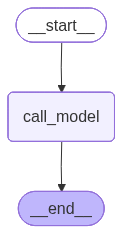

[INFO] 图编译完成，已关联 checkpointer 和 store


In [ ]:
import os
import uuid
from dotenv import load_dotenv
from pydantic import SecretStr

# LangGraph & LangChain 相关导入
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.config import get_store
from langchain_deepseek import ChatDeepSeek
from langchain_openai import OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

# 加载环境变量（.env 文件中需要定义 DEEPSEEK_API_KEY 和 DEEPSEEK_BASE_URL）
load_dotenv()

# ==================== 1. 初始化存储（长期记忆） ====================
# 注意：变量名统一为 in_memory_store，后面 compile 时使用
in_memory_store = InMemoryStore(
    index={
        "embed": OpenAIEmbeddings(
            model="Pro/BAAI/bge-m3",
            api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
            base_url=os.getenv("DEEPSEEK_BASE_URL"),
        ),
        "dims": 1024,
    }
)
print("[INFO] InMemoryStore 已创建，类型:", type(in_memory_store))

# ==================== 2. 初始化模型 ====================
model = ChatDeepSeek(
    model="deepseek-chat",
    api_key=SecretStr(os.getenv("DEEPSEEK_API_KEY") or ""),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
)
print("[INFO] ChatDeepSeek 模型已初始化")

# ==================== 3. 定义节点函数 ====================
def call_model(state: MessagesState, config: RunnableConfig):
    """
    节点函数：检索/存储用户记忆，并调用模型生成回复。
    使用 get_store() 获取 store 实例，而不是通过参数注入。
    """
    # 获取 store（必须是已经通过 compile(store=...) 传入的）
    store = get_store()
    if store is None:
        raise RuntimeError(
            "Store 未注入！请确保在编译图时调用了 builder.compile(store=in_memory_store)"
        )

    # RunnableConfig 是 TypedDict，其中 configurable 是 NotRequired；需要安全访问
    configurable = config["configurable"] if "configurable" in config else {}
    namespace = configurable.get("thread_id", "default_thread")

    last_msg = state["messages"][-1]
    raw_content = last_msg.content

    # 规范化 content -> 纯字符串
    if isinstance(raw_content, str):
        query = raw_content
    elif isinstance(raw_content, list):
        texts: list[str] = []
        for item in raw_content:
            if isinstance(item, str):
                texts.append(item)
            elif isinstance(item, dict) and "text" in item:
                texts.append(str(item["text"]))
        query = " ".join(texts) if texts else ""
    else:
        query = str(raw_content)   # 回退

    # 现在 query 是 str 类型
    memories = store.search(namespace, query=query, limit=5)
    info_lines: list[str] = []
    for mem in memories:
        # mem 是 StoreItem 对象，属性包括 value, key, namespace, metadata
        text = mem.value.get("text", "") if isinstance(mem.value, dict) else str(mem.value)
        info_lines.append(text)
    info = "\n".join(info_lines)
    print(f"[INFO] 检索到的记忆:\n{info if info else '（无）'}")

    # ---------- 存储记忆（如果用户要求记住） ----------
    if "记住" in query:
        key = str(uuid.uuid4())
        # 将消息内容存入 store
        store.put(
            namespace=namespace,
            key=key,
            value={"text": query},
            metadata={"text": query, "timestamp": str(uuid.uuid1())},
        )
        print(f"[INFO] 已存储记忆，key={key}")

    # ---------- 调用模型 ----------
    # 构造系统消息，包含检索到的用户信息
    system_content = f"你是一个正在与用户交谈的AI小助手。用户的相关信息如下：\n{info}\n请基于这些信息友好地回答用户。"
    messages = [SystemMessage(content=system_content)] + state["messages"]
    response = model.invoke(messages)
    print("[INFO] 模型响应已生成")

    # 返回新消息（归约器会自动追加到 messages 列表中）
    return {"messages": [response]}

# ==================== 4. 构建图 ====================
builder = StateGraph(MessagesState)
builder.add_node(call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

# 同时配置短期记忆（checkpointer）和长期记忆（store）
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer, store=in_memory_store)
print("[INFO] 图编译完成，已关联 checkpointer 和 store")

In [69]:
config = {"configurable": {"user_id": "user123","thread_id": "thread123"}}
input_message = HumanMessage(content="hello,记住我是hakimi")
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

hello,记住我是hakimi


NotFoundError: Error code: 404

跨线程查询


In [42]:
config = {"configurable": {"user_id": "user123","thread_id": "thread124"}}
input_message = HumanMessage(content="hello,我叫什么名字?")
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

hello,我叫什么名字?


TypeError: call_model() missing 1 required positional argument: 'store'